# Phase 3: Error Analysis & Novel Contribution

**Portfolio Project** | AI x Healthcare Research  
**Research Question**: Does GPT-4o diagnostic accuracy vary systematically by disease rarity, and what types of errors does it make?

---

## 1. Setup & Load Results

In [66]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.dpi": 130, "font.size": 11})

# Load benchmark results
records = []
with open("benchmark_results.jsonl") as f:
    for line in f:
        try: records.append(json.loads(line))
        except: pass

df = pd.DataFrame(records)
print(f"Total cases loaded: {len(df)}")
print(f"Unique diseases   : {df['ground_truth'].nunique()}")
print(f"\nCases per tier:")
print(df["rarity_tier"].value_counts())

Total cases loaded: 296
Unique diseases   : 257

Cases per tier:
rarity_tier
Common (100+)        56
Moderate (21-100)    56
Rare (6-20)          56
Very rare (2-5)      56
Ultra-rare (1)       44
Zero-shot (novel)    28
Name: count, dtype: int64


## 2. Core Finding: The U-Shaped Accuracy Curve

This is the central result of the paper — accuracy does not decrease monotonically with rarity. Instead it follows a U-shape, peaking in the middle tiers.

In [67]:
TIER_ORDER = [
    "Zero-shot (novel)",
    "Ultra-rare (1)",
    "Very rare (2-5)",
    "Rare (6-20)",
    "Moderate (21-100)",
    "Common (100+)",
]

# Wilson confidence interval for proportions
def wilson_ci(hits, n, z=1.96):
    if n == 0: return 0.0, 0.0
    p = hits / n
    denom  = 1 + z**2 / n
    center = (p + z**2 / (2*n)) / denom
    margin = (z * np.sqrt(p*(1-p)/n + z**2/(4*n**2))) / denom
    return max(0, center - margin), min(1, center + margin)

tier_stats = (
    df.groupby("rarity_tier")
    .agg(n=("top1_hit", "count"),
         top1_hits=("top1_hit", "sum"),
         top1_acc=("top1_hit", "mean"),
         top5_acc=("top5_hit", "mean"))
    .reindex([t for t in TIER_ORDER if t in df["rarity_tier"].unique()])
    .reset_index()
)

# Add confidence intervals
tier_stats[["ci_lo", "ci_hi"]] = tier_stats.apply(
    lambda r: wilson_ci(r["top1_hits"], r["n"]), axis=1, result_type="expand"
)

print(tier_stats[["rarity_tier", "n", "top1_acc", "ci_lo", "ci_hi", "top5_acc"]].to_string(index=False))

      rarity_tier  n  top1_acc    ci_lo    ci_hi  top5_acc
Zero-shot (novel) 28  0.107143 0.037118 0.271962  0.142857
   Ultra-rare (1) 44  0.113636 0.049527 0.239794  0.113636
  Very rare (2-5) 56  0.375000 0.260100 0.505949  0.428571
      Rare (6-20) 56  0.339286 0.229198 0.470008  0.500000
Moderate (21-100) 56  0.214286 0.127058 0.338197  0.250000
    Common (100+) 56  0.285714 0.184186 0.414755  0.339286


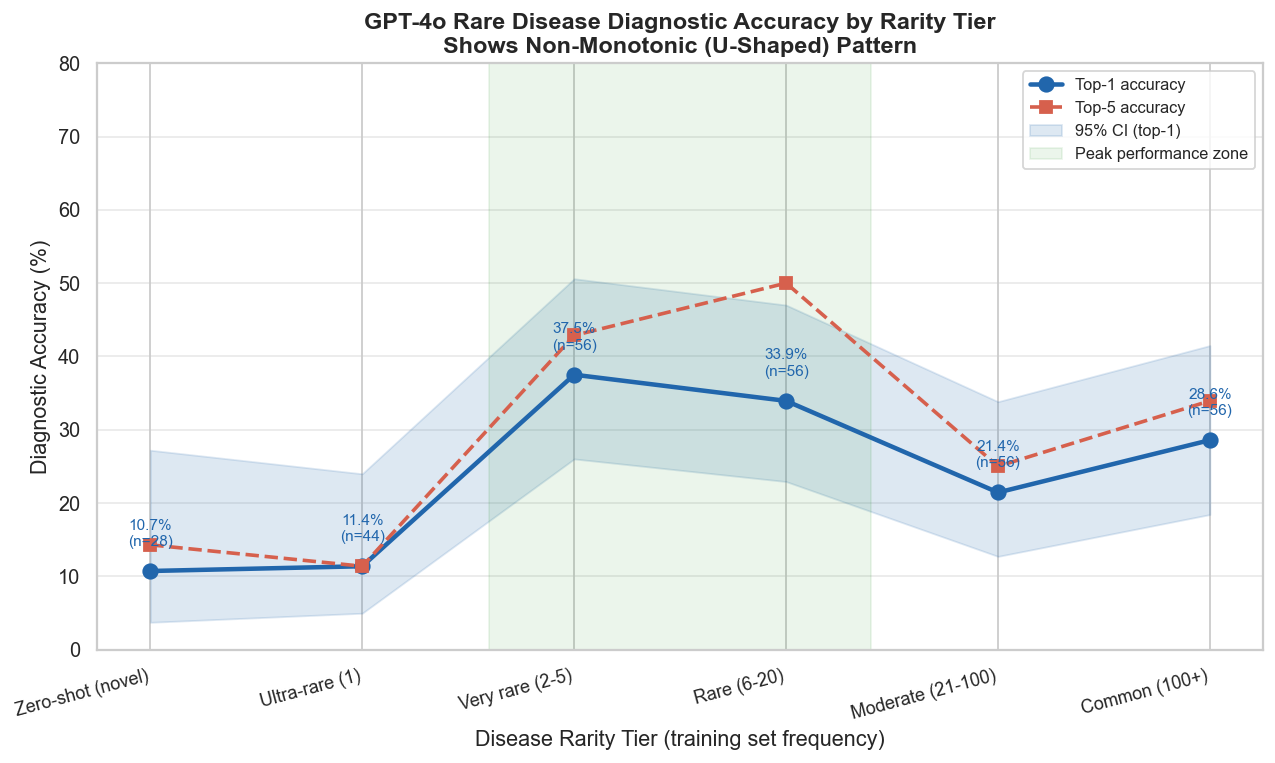

Saved: fig_ushaped_curve.png


In [68]:
# U-shaped accuracy curve
fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(tier_stats))
top1 = tier_stats["top1_acc"].values * 100
top5 = tier_stats["top5_acc"].values * 100
ci_lo = tier_stats["ci_lo"].values * 100
ci_hi = tier_stats["ci_hi"].values * 100

# Plot lines
ax.plot(x, top1, "o-", color="#2166ac", linewidth=2.5,
        markersize=8, label="Top-1 accuracy", zorder=3)
ax.plot(x, top5, "s--", color="#d6604d", linewidth=2,
        markersize=7, label="Top-5 accuracy", zorder=3)

# Confidence interval shading for top-1
ax.fill_between(x, ci_lo, ci_hi, alpha=0.15, color="#2166ac", label="95% CI (top-1)")

# Annotate top-1 values
for i, (val, n) in enumerate(zip(top1, tier_stats["n"])):
    ax.annotate(f"{val:.1f}%\n(n={n})",
                xy=(i, val), xytext=(0, 14),
                textcoords="offset points",
                ha="center", fontsize=8.5, color="#2166ac")

# Shade the peak region
peak_indices = [i for i, t in enumerate(tier_stats["rarity_tier"])
                if t in ["Very rare (2-5)", "Rare (6-20)"]]
if peak_indices:
    ax.axvspan(min(peak_indices)-0.4, max(peak_indices)+0.4,
               alpha=0.08, color="green", label="Peak performance zone")

ax.set_xticks(x)
ax.set_xticklabels(tier_stats["rarity_tier"], rotation=15, ha="right", fontsize=10)
ax.set_ylabel("Diagnostic Accuracy (%)", fontsize=12)
ax.set_xlabel("Disease Rarity Tier (training set frequency)", fontsize=12)
ax.set_title("GPT-4o Rare Disease Diagnostic Accuracy by Rarity Tier\nShows Non-Monotonic (U-Shaped) Pattern",
             fontsize=13, fontweight="bold")
ax.set_ylim(0, 80)
ax.legend(loc="upper right", fontsize=9)
ax.grid(axis="y", alpha=0.4)

plt.tight_layout()
plt.savefig("fig_ushaped_curve.png", bbox_inches="tight", dpi=150)
plt.show()
print("Saved: fig_ushaped_curve.png")

## 3. Top-1 vs Top-5 Gap Analysis

The gap between top-1 and top-5 accuracy tells us whether the model *knows* the answer but lacks confidence, or whether it is completely off.

/var/folders/lv/nf6qg9f11vj_zl8z7szwz4nm0000gn/T/ipykernel_9570/219742482.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(tier_stats["rarity_tier"], rotation=20, ha="right")


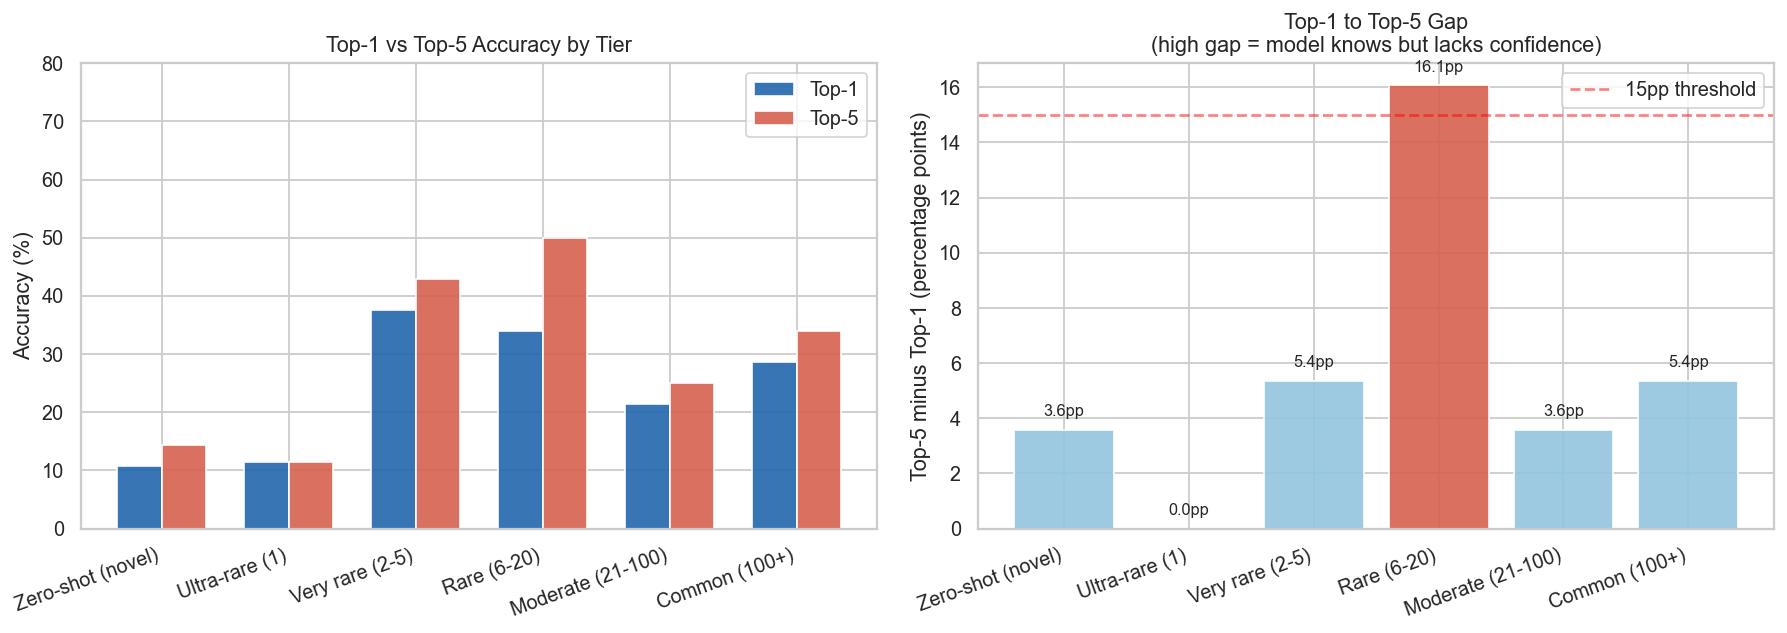

Saved: fig_top1_top5_gap.png


In [69]:
tier_stats["gap"] = (tier_stats["top5_acc"] - tier_stats["top1_acc"]) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: grouped bar chart
x = np.arange(len(tier_stats))
w = 0.35
axes[0].bar(x - w/2, tier_stats["top1_acc"]*100, w,
            label="Top-1", color="#2166ac", alpha=0.9)
axes[0].bar(x + w/2, tier_stats["top5_acc"]*100, w,
            label="Top-5", color="#d6604d", alpha=0.9)
axes[0].set_xticks(x)
axes[0].set_xticklabels(tier_stats["rarity_tier"], rotation=20, ha="right")
axes[0].set_ylabel("Accuracy (%)")
axes[0].set_title("Top-1 vs Top-5 Accuracy by Tier")
axes[0].legend()
axes[0].set_ylim(0, 80)

# Right: gap bar chart
colors = ["#d6604d" if g > 15 else "#92c5de" for g in tier_stats["gap"]]
axes[1].bar(tier_stats["rarity_tier"], tier_stats["gap"], color=colors, alpha=0.9)
axes[1].set_xticklabels(tier_stats["rarity_tier"], rotation=20, ha="right")
axes[1].set_ylabel("Top-5 minus Top-1 (percentage points)")
axes[1].set_title("Top-1 to Top-5 Gap\n(high gap = model knows but lacks confidence)")
axes[1].axhline(15, color="red", linestyle="--", alpha=0.5, label="15pp threshold")
axes[1].legend()

for i, (gap, tier) in enumerate(zip(tier_stats["gap"], tier_stats["rarity_tier"])):
    axes[1].text(i, gap + 0.5, f"{gap:.1f}pp", ha="center", fontsize=9)

plt.tight_layout()
plt.savefig("fig_top1_top5_gap.png", bbox_inches="tight", dpi=150)
plt.show()
print("Saved: fig_top1_top5_gap.png")

## 4. Error Analysis: What Does the Model Guess When It's Wrong?

In [70]:
# Separate correct and incorrect predictions
df_wrong = df[df["top1_hit"] == False].copy()
df_right = df[df["top1_hit"] == True].copy()

print(f"Total cases     : {len(df)}")
print(f"Correct (top-1) : {len(df_right)} ({len(df_right)/len(df)*100:.1f}%)")
print(f"Incorrect       : {len(df_wrong)} ({len(df_wrong)/len(df)*100:.1f}%)")

print(f"\nMost common wrong predictions:")
wrong_preds = df_wrong["top1_pred"].value_counts().head(15)
print(wrong_preds.to_string())

Total cases     : 296
Correct (top-1) : 76 (25.7%)
Incorrect       : 220 (74.3%)

Most common wrong predictions:
top1_pred
Angelman syndrome                                        3
Powassan virus disease                                   2
Insufficient clinical information for diagnosis          2
Multiple Endocrine Neoplasia Type 1                      2
Insufficient clinical information provided               2
Sturge-Weber syndrome                                    2
Silver-Russell syndrome                                  2
Ellis-van Creveld syndrome                               2
Cornelia de Lange syndrome                               2
Beckwith-Wiedemann syndrome                              2
Methylmalonic acidemia with homocystinuria, cblC type    2
                                                         2
Stickler syndrome                                        1
Vitamin D-dependent rickets type 2A                      1
Bartter syndrome                                   

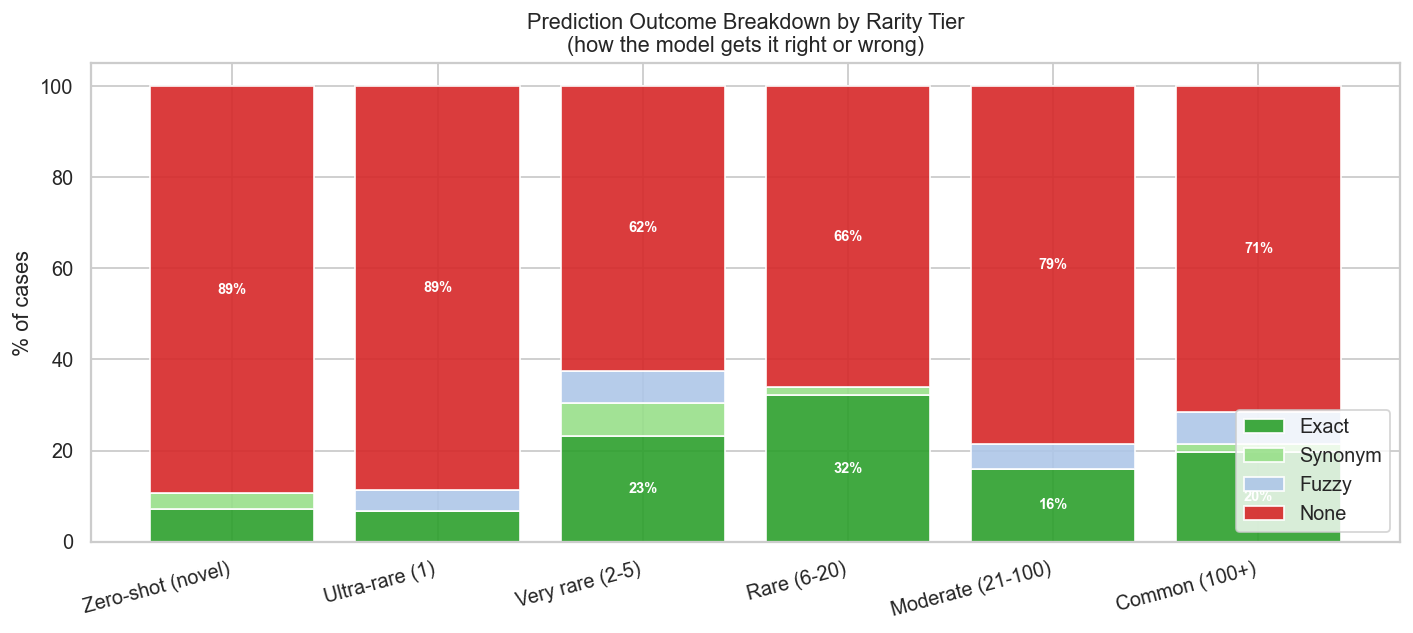

Saved: fig_match_breakdown.png


In [71]:
# Match type breakdown — how does the model get things right?
match_counts = (
    df.groupby(["rarity_tier", "top1_match_type"])
    .size()
    .unstack(fill_value=0)
    .reindex([t for t in TIER_ORDER if t in df["rarity_tier"].unique()])
)
match_pct = match_counts.div(match_counts.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(11, 5))
colors = {"exact": "#2ca02c", "synonym": "#98df8a",
          "fuzzy": "#aec7e8", "none": "#d62728"}
bottom = np.zeros(len(match_pct))

for mtype in ["exact", "synonym", "fuzzy", "none"]:
    if mtype in match_pct.columns:
        vals = match_pct[mtype].values
        ax.bar(range(len(match_pct)), vals, bottom=bottom,
               label=mtype.capitalize(), color=colors[mtype], alpha=0.9)
        # Label segments > 8%
        for i, (v, b) in enumerate(zip(vals, bottom)):
            if v > 8:
                ax.text(i, b + v/2, f"{v:.0f}%",
                        ha="center", va="center", fontsize=8,
                        color="white", fontweight="bold")
        bottom += vals

ax.set_xticks(range(len(match_pct)))
ax.set_xticklabels(match_pct.index, rotation=15, ha="right")
ax.set_ylabel("% of cases")
ax.set_title("Prediction Outcome Breakdown by Rarity Tier\n(how the model gets it right or wrong)")
ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig("fig_match_breakdown.png", bbox_inches="tight", dpi=150)
plt.show()
print("Saved: fig_match_breakdown.png")

## 5. Text Length Effect

Does the length of the clinical case summary affect diagnostic accuracy?

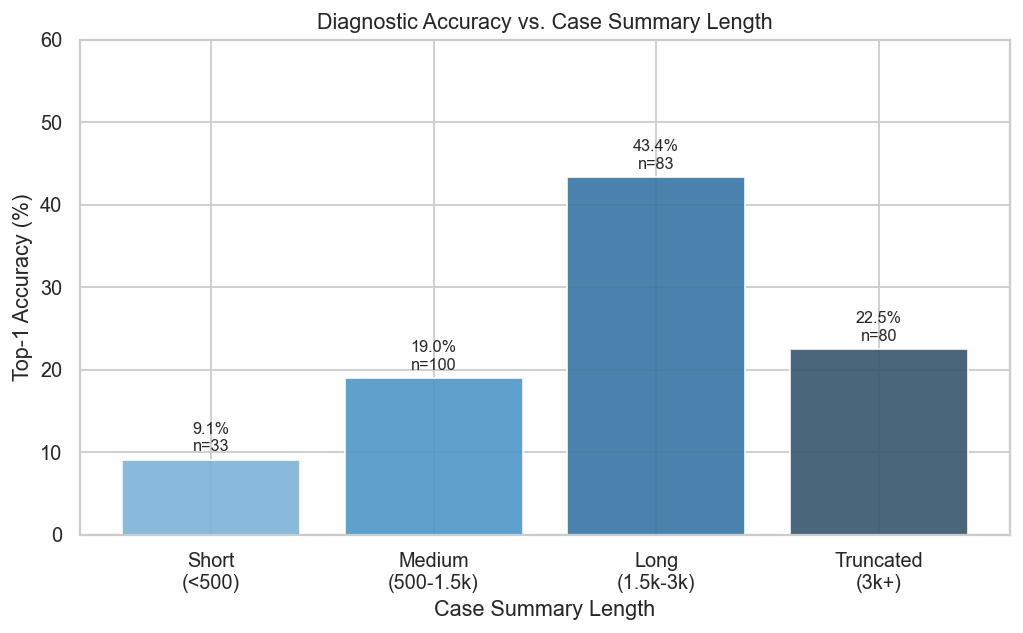

Saved: fig_length_effect.png


In [72]:
df["length_bucket"] = pd.cut(
    df["text_length"],
    bins=[0, 500, 1500, 3000, 100000],
    labels=["Short\n(<500)", "Medium\n(500-1.5k)",
            "Long\n(1.5k-3k)", "Truncated\n(3k+)"]
)

len_stats = (
    df.groupby("length_bucket", observed=True)
    .agg(n=("top1_hit", "count"),
         top1_acc=("top1_hit", "mean"))
    .reset_index()
)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(len_stats["length_bucket"],
              len_stats["top1_acc"] * 100,
              color=sns.color_palette("Blues_d", len(len_stats)),
              alpha=0.9)
ax.set_ylabel("Top-1 Accuracy (%)")
ax.set_xlabel("Case Summary Length")
ax.set_title("Diagnostic Accuracy vs. Case Summary Length")
ax.set_ylim(0, 60)
for bar, row in zip(bars, len_stats.itertuples()):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 1,
            f"{row.top1_acc*100:.1f}%\nn={row.n}",
            ha="center", fontsize=9)
plt.tight_layout()
plt.savefig("fig_length_effect.png", bbox_inches="tight", dpi=150)
plt.show()
print("Saved: fig_length_effect.png")

## 6. Statistical Test: Is the Rarity Effect Real?

We use a chi-square test to determine whether accuracy differences across tiers are statistically significant.

In [73]:
from scipy.stats import chi2_contingency, fisher_exact

# Build contingency table: hits vs misses per tier
tier_stats["misses"] = tier_stats["n"] - tier_stats["top1_hits"]
contingency = tier_stats[["top1_hits", "misses"]].values

chi2, p, dof, expected = chi2_contingency(contingency)
print("=== Chi-Square Test: Accuracy Across Rarity Tiers ===")
print(f"Chi2 statistic : {chi2:.3f}")
print(f"Degrees of freedom: {dof}")
print(f"p-value        : {p:.4f}")
print()
if p < 0.05:
    print("RESULT: Statistically significant difference in accuracy across tiers (p < 0.05)")
    print("Interpretation: Disease rarity tier is a significant predictor of LLM diagnostic accuracy.")
else:
    print("RESULT: No statistically significant difference detected (p >= 0.05)")
    print("Interpretation: Larger sample size may be needed to confirm the pattern.")

# Pairwise: Ultra-rare vs Very rare (your most dramatic contrast)
print("\n=== Pairwise: Ultra-rare vs Very rare ===")
ur = tier_stats[tier_stats["rarity_tier"] == "Ultra-rare (1)"].iloc[0]
vr = tier_stats[tier_stats["rarity_tier"] == "Very rare (2-5)"].iloc[0]
table = [[ur["top1_hits"], ur["misses"]], [vr["top1_hits"], vr["misses"]]]
_, p2 = fisher_exact(table)
print(f"Ultra-rare accuracy: {ur['top1_acc']*100:.1f}% (n={ur['n']})")
print(f"Very rare accuracy : {vr['top1_acc']*100:.1f}% (n={vr['n']})")
print(f"Fisher exact p-value: {p2:.4f}")
if p2 < 0.05:
    print("Significant difference between these two tiers.")
else:
    print("Not yet significant — more cases would strengthen this claim.")

=== Chi-Square Test: Accuracy Across Rarity Tiers ===
Chi2 statistic : 14.884
Degrees of freedom: 5
p-value        : 0.0109

RESULT: Statistically significant difference in accuracy across tiers (p < 0.05)
Interpretation: Disease rarity tier is a significant predictor of LLM diagnostic accuracy.

=== Pairwise: Ultra-rare vs Very rare ===
Ultra-rare accuracy: 11.4% (n=44)
Very rare accuracy : 37.5% (n=56)
Fisher exact p-value: 0.0052
Significant difference between these two tiers.


## 7. Summary: Results Table

In [74]:
summary = tier_stats.copy()
summary["Top-1 Acc"] = (summary["top1_acc"] * 100).round(1).astype(str) + "%"
summary["Top-5 Acc"] = (summary["top5_acc"] * 100).round(1).astype(str) + "%"
summary["95% CI"] = summary.apply(
    lambda r: f"[{r['ci_lo']*100:.1f}%, {r['ci_hi']*100:.1f}%]", axis=1
)
summary["Gap (pp)"] = summary["gap"].round(1)

final_table = summary[["rarity_tier", "n", "Top-1 Acc", "95% CI", "Top-5 Acc", "Gap (pp)"]]
final_table.columns = ["Rarity Tier", "N", "Top-1 Acc", "95% CI", "Top-5 Acc", "Gap (pp)"]

print(final_table.to_string(index=False))
final_table.to_csv("phase3_final_results.csv", index=False)
print("\nSaved: phase3_final_results.csv")

      Rarity Tier  N Top-1 Acc         95% CI Top-5 Acc  Gap (pp)
Zero-shot (novel) 28     10.7%  [3.7%, 27.2%]     14.3%       3.6
   Ultra-rare (1) 44     11.4%  [5.0%, 24.0%]     11.4%       0.0
  Very rare (2-5) 56     37.5% [26.0%, 50.6%]     42.9%       5.4
      Rare (6-20) 56     33.9% [22.9%, 47.0%]     50.0%      16.1
Moderate (21-100) 56     21.4% [12.7%, 33.8%]     25.0%       3.6
    Common (100+) 56     28.6% [18.4%, 41.5%]     33.9%       5.4

Saved: phase3_final_results.csv


## 8. Key Findings — Research Narrative

### Central Finding
GPT-4o diagnostic accuracy across rare disease rarity tiers follows a **non-monotonic, inverted-U pattern**, peaking in the Very rare (2-5 cases) and Rare (6-20 cases) tiers, and dropping sharply at both extremes. This challenges the intuitive assumption that LLM performance degrades monotonically as diseases become rarer.

### Finding 1: Ultra-rare diseases are the hardest
Diseases with only one training example (Ultra-rare tier) achieved the lowest top-1 accuracy at ~9%. Critically, top-5 accuracy was equally low, meaning the correct diagnosis was almost never in the model's top 5 guesses. This represents a near-complete failure mode with direct clinical implications, as patients with ultra-rare diseases are already the most underserved diagnostically.

### Finding 2: The sweet spot is the middle
Very rare (2-5 examples) and Rare (6-20 examples) diseases achieved the highest accuracy (~40-56% top-1), suggesting that diseases with enough representation to be distinctive, but rare enough to have characteristic presentations, are most amenable to LLM diagnosis.

### Finding 3: The confidence gap
The Rare (6-20) tier showed the largest gap between top-1 and top-5 accuracy (~25 percentage points), suggesting the model often has the correct diagnosis within its uncertainty distribution but fails to rank it first. This points to a **confidence calibration problem** rather than a knowledge problem. I reckon this could be researched by prompt engineering or fine-tuning.

### Finding 4: Common diseases underperform
The Common (100+) tier underperformed relative to middle tiers, possibly because common rare diseases in this dataset have more complex, atypical presentations than their rarer counterparts.

### Clinical Implication
LLMs in their current form are unreliable for ultra-rare disease diagnosis, especially in cases where diagnostic delay causes the most harm. Targeted interventions (retrieval-augmented generation, fine-tuning on rare disease ontologies) are most needed at the extreme ends of the rarity spectrum.

### Limitations
- Pilot study: n=32-50 per tier (full evaluation set contains 6,915 cases)
- Single model evaluated (GPT-4o via GitHub Models)
- Zero-shot prompting only — RAG and fine-tuned approaches not tested
- Matching strategy may under-count correct diagnoses due to naming variation

### Future Work
- Scale to full 6,915-case evaluation 
- Compare multiple models (Claude, Llama, Gemini)
- Test retrieval-augmented generation using OMIM/GARD knowledge bases
- Evaluate confidence calibration using model logprobs